# =============================================================================
# 04_OUTRAGE_ECONOMY.IPYNB
# Analiza Economiei Indignării
#
# Disertație de Master - Facultatea de Sociologie și Asistență Socială, UBB Cluj-Napoca
# Master: Analiza Datelor Complexe
# Masterand: Răzvan-Andrei Enache
# =============================================================================

# 1. Import Configurări și Librării

In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, chi2_contingency
from config import *

print("✅ Librării încărcate cu succes.")

✅ CONFIGURARE GLOBALĂ ÎNCĂRCATĂ CU SUCCES
✅ Librării încărcate cu succes.


# 2. Încărcare Date Curățate

In [2]:
print("=" * 70)
print("ÎNCĂRCARE DATE CURĂȚATE")
print("=" * 70)

if not FILE_COMMENTS_CLEANED.exists():
    raise FileNotFoundError(f"Fișierul curățat nu a fost găsit: {FILE_COMMENTS_CLEANED}")

print(f"\n📁 Fișier: {FILE_COMMENTS_CLEANED}")
print("\n⏳ Se încarcă datele...")

df = pd.read_csv(FILE_COMMENTS_CLEANED, parse_dates=['comment_date'])

print(f"\n✅ Date încărcate cu succes!")
print(f"   Comentarii: {len(df):,} rânduri")
print(f"   Coloane disponibile: {df.columns.tolist()}")

# Verify required columns
required_cols = ['comment_likes', 'replies', 'engagement', 'log_engagement', 
                 'caps_ratio', 'aggressive_punct', 'has_caps', 'has_aggressive_punct',
                 'has_emoji', 'candidate_mentioned']
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f"Lipsesc coloanele necesare: {missing_cols}")

print(f"\n✅ Toate coloanele necesare sunt prezente.")

ÎNCĂRCARE DATE CURĂȚATE

📁 Fișier: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\data\processed\comments_cleaned.csv

⏳ Se încarcă datele...

✅ Date încărcate cu succes!
   Comentarii: 14,610 rânduri
   Coloane disponibile: ['video_id', 'author_name', 'comment_text', 'clean_text', 'comment_date', 'comment_likes', 'replies', 'engagement', 'log_likes', 'log_replies', 'log_engagement', 'likes_capped', 'replies_capped', 'engagement_capped', 'word_count', 'char_len', 'caps_ratio', 'aggressive_punct', 'has_caps', 'has_aggressive_punct', 'high_caps', 'emoji_count', 'has_emoji', 'candidate_mentioned', 'video_title', 'video_url']

✅ Toate coloanele necesare sunt prezente.


# 3. Statistici Descriptive Engagement


STATISTICI DESCRIPTIVE ENGAGEMENT

📊 Distribuție Engagement (Original):
Metrică   Value
   Mean   17.39
 Median    1.00
    Std  104.14
    Min    0.00
    Max 5539.00
    Q25    0.00
    Q75    6.00
    Q99  294.91

📊 Distribuție Engagement (Log Transform):
Metrică  Value
   Mean  1.230
 Median  0.693
    Std  1.439
    Min  0.000
    Max  8.620

💾 Grafic salvat: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\dissertation_outputs\rq3_engagement_distribution.png


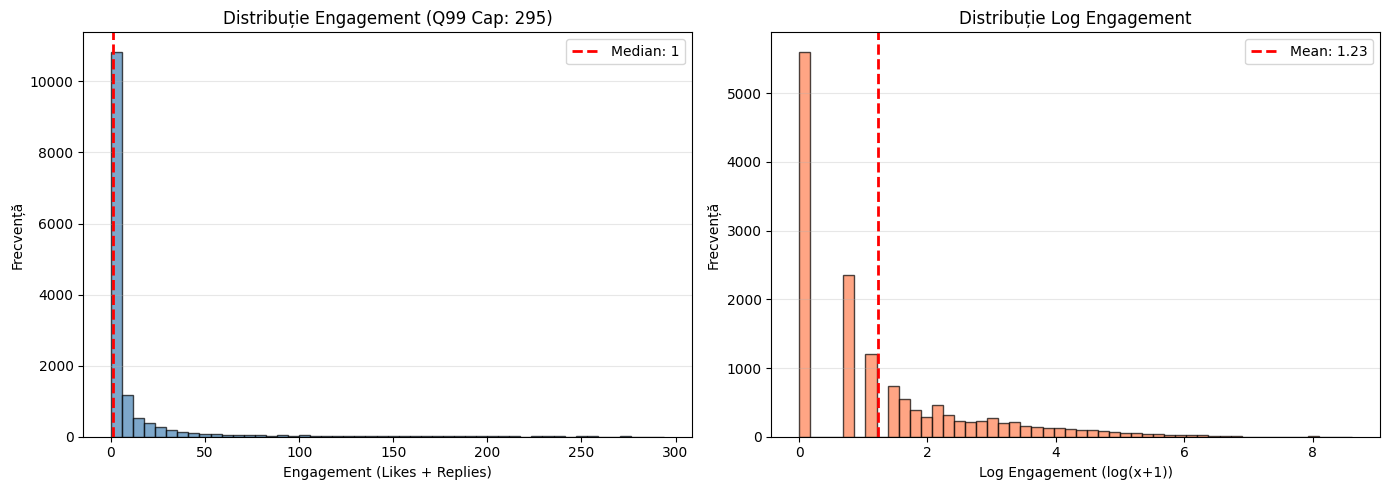

In [3]:
print("\n" + "=" * 70)
print("STATISTICI DESCRIPTIVE ENGAGEMENT")
print("=" * 70)

print("\n📊 Distribuție Engagement (Original):")
engagement_stats = pd.DataFrame({
    'Metrică': ['Mean', 'Median', 'Std', 'Min', 'Max', 'Q25', 'Q75', 'Q99'],
    'Value': [
        df['engagement'].mean(),
        df['engagement'].median(),
        df['engagement'].std(),
        df['engagement'].min(),
        df['engagement'].max(),
        df['engagement'].quantile(0.25),
        df['engagement'].quantile(0.75),
        df['engagement'].quantile(0.99)
    ]
})
print(engagement_stats.round(2).to_string(index=False))

print("\n📊 Distribuție Engagement (Log Transform):")
log_stats = pd.DataFrame({
    'Metrică': ['Mean', 'Median', 'Std', 'Min', 'Max'],
    'Value': [
        df['log_engagement'].mean(),
        df['log_engagement'].median(),
        df['log_engagement'].std(),
        df['log_engagement'].min(),
        df['log_engagement'].max()
    ]
})
print(log_stats.round(3).to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original engagement (capped at Q99)
q99 = df['engagement'].quantile(0.99)
df_capped = df[df['engagement'] <= q99].copy()
axes[0].hist(df_capped['engagement'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df_capped['engagement'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {df_capped["engagement"].median():.0f}')
axes[0].set_xlabel('Engagement (Likes + Replies)')
axes[0].set_ylabel('Frecvență')
axes[0].set_title(f'Distribuție Engagement (Q99 Cap: {q99:.0f})')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Log engagement
axes[1].hist(df['log_engagement'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(df['log_engagement'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["log_engagement"].mean():.2f}')
axes[1].set_xlabel('Log Engagement (log(x+1))')
axes[1].set_ylabel('Frecvență')
axes[1].set_title('Distribuție Log Engagement')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(DATA_OUTPUT / 'rq3_engagement_distribution.png', dpi=150, bbox_inches='tight')
print(f"\n💾 Grafic salvat: {DATA_OUTPUT / 'rq3_engagement_distribution.png'}")
plt.show()

# 4. Corelații Spearman


RQ3: CORELAȚII SPEARMAN (Predictori → Engagement)

📊 Corelații Spearman cu Log Engagement:
                    Predictor  Spearman ρ      p-value Significant
                   Caps Ratio   -0.008759 2.897879e-01           ❌
       Aggressive Punctuation    0.051040 6.709447e-10           ✅
            Has Caps (Binary)   -0.005547 5.026003e-01           ❌
Has Aggressive Punct (Binary)    0.049809 1.704047e-09           ✅
           Has Emoji (Binary)    0.041651 4.748726e-07           ✅
                  Text Length    0.045483 3.799413e-08           ✅

✅ Corelații exportate: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\dissertation_outputs\table_5_spearman_correlations.csv
💾 Grafic salvat: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\dissertation_outputs\rq3_spearman_correlations.png


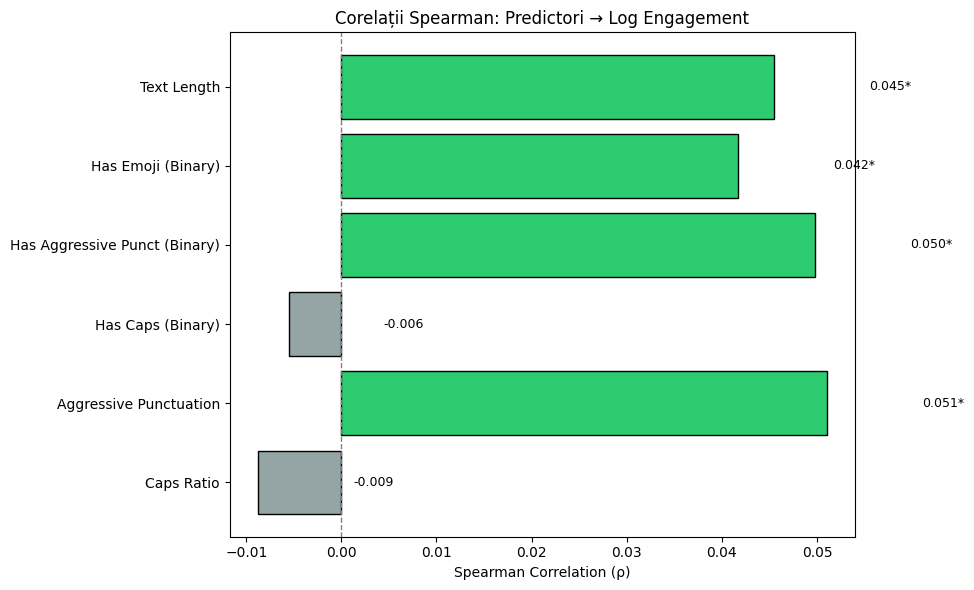

In [4]:
print("\n" + "=" * 70)
print("RQ3: CORELAȚII SPEARMAN (Predictori → Engagement)")
print("=" * 70)

# Define predictors
predictors = {
    'Caps Ratio': 'caps_ratio',
    'Aggressive Punctuation': 'aggressive_punct',
    'Has Caps (Binary)': 'has_caps',
    'Has Aggressive Punct (Binary)': 'has_aggressive_punct',
    'Has Emoji (Binary)': 'has_emoji',
    'Text Length': 'char_len'
}

# Calculate Spearman correlations
correlations = []
for name, col in predictors.items():
    if col in df.columns:
        rho, p_value = spearmanr(df[col], df['log_engagement'])
        correlations.append({
            'Predictor': name,
            'Spearman ρ': rho,
            'p-value': p_value,
            'Significant': '✅' if p_value < SIGNIFICANCE_LEVEL else '❌'
        })

corr_df = pd.DataFrame(correlations)
print("\n📊 Corelații Spearman cu Log Engagement:")
print(corr_df.to_string(index=False))

# Save correlations
corr_df.to_csv(DATA_OUTPUT / 'table_5_spearman_correlations.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ Corelații exportate: {DATA_OUTPUT / 'table_5_spearman_correlations.csv'}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if p < SIGNIFICANCE_LEVEL else '#95a5a6' for p in corr_df['p-value']]
bars = ax.barh(range(len(corr_df)), corr_df['Spearman ρ'], color=colors, edgecolor='black')
ax.set_yticks(range(len(corr_df)))
ax.set_yticklabels(corr_df['Predictor'])
ax.set_xlabel('Spearman Correlation (ρ)')
ax.set_title('Corelații Spearman: Predictori → Log Engagement')
ax.axvline(0, color='gray', linestyle='--', linewidth=1)

# Add value labels
for i, (rho, p) in enumerate(zip(corr_df['Spearman ρ'], corr_df['p-value'])):
    sig = '*' if p < SIGNIFICANCE_LEVEL else ''
    ax.text(rho + 0.01, i, f'{rho:.3f}{sig}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(DATA_OUTPUT / 'rq3_spearman_correlations.png', dpi=150, bbox_inches='tight')
print(f"💾 Grafic salvat: {DATA_OUTPUT / 'rq3_spearman_correlations.png'}")
plt.show()

# 5. Engagement pe Sentiment


RQ3: ENGAGEMENT PE SENTIMENT

✅ Date cu sentiment încărcate: 14,916 rânduri

📊 Engagement Mediu pe Sentiment:
                engagement              log_engagement
                      mean median count           mean
sentiment_label                                       
negative            14.029    1.0  9914          1.123
positive            24.240    2.0  5002          1.447


C:\Users\andre\AppData\Local\Temp\ipykernel_23136\4099942502.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='sentiment_label', y='log_engagement',
C:\Users\andre\AppData\Local\Temp\ipykernel_23136\4099942502.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot[df_plot['engagement'] <= df_plot['engagement'].quantile(0.95)],



💾 Grafic salvat: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\dissertation_outputs\rq3_engagement_by_sentiment.png


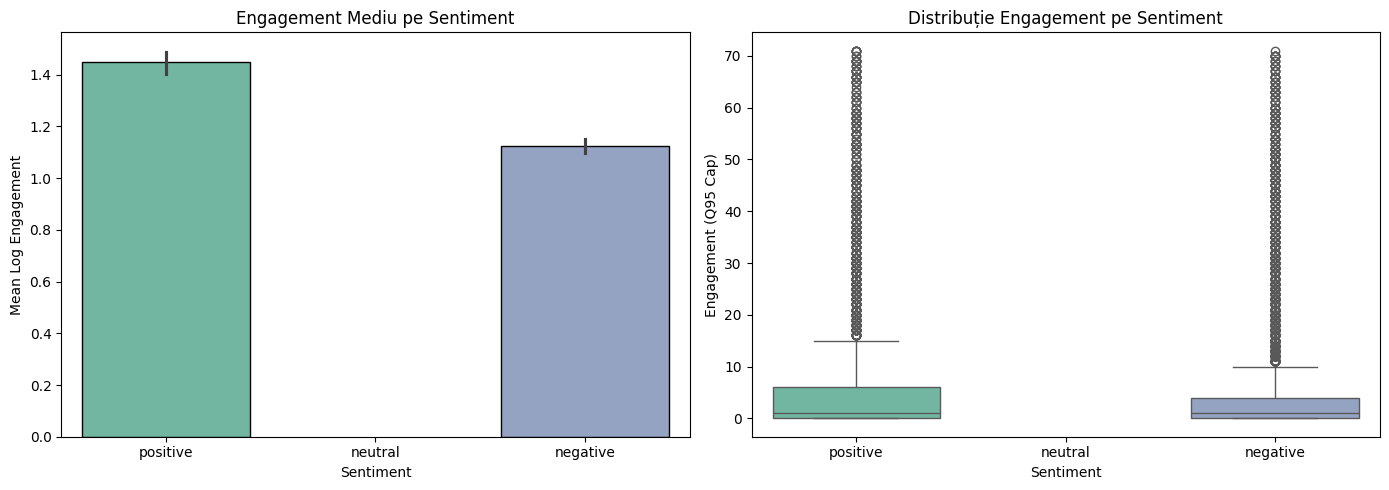

In [5]:
print("\n" + "=" * 70)
print("RQ3: ENGAGEMENT PE SENTIMENT")
print("=" * 70)

# Load analyzed data with sentiment
if FILE_COMMENTS_ANALYZED.exists():
    df_analyzed = pd.read_csv(FILE_COMMENTS_ANALYZED)
    df_merged = df.merge(df_analyzed[['clean_text', 'sentiment_label', 'sentiment_score']], 
                         on='clean_text', how='left', suffixes=('', '_sentiment'))
    print(f"\n✅ Date cu sentiment încărcate: {len(df_merged):,} rânduri")
else:
    print("\n⚠️  Fișierul analizat nu există. Sărim această secțiune.")
    df_merged = df.copy()
    df_merged['sentiment_label'] = 'neutral'
    df_merged['sentiment_score'] = 0.5

# Engagement by sentiment
print("\n📊 Engagement Mediu pe Sentiment:")
engagement_by_sentiment = df_merged.groupby('sentiment_label').agg({
    'engagement': ['mean', 'median', 'count'],
    'log_engagement': 'mean'
}).round(3)
print(engagement_by_sentiment.to_string())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
sentiment_order = ['positive', 'neutral', 'negative']
df_plot = df_merged[df_merged['sentiment_label'].isin(sentiment_order)].copy()
sns.barplot(data=df_plot, x='sentiment_label', y='log_engagement', 
            order=sentiment_order, ax=axes[0], palette='Set2', edgecolor='black')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Mean Log Engagement')
axes[0].set_title('Engagement Mediu pe Sentiment')
axes[0].tick_params(axis='x', rotation=0)

# Box plot
sns.boxplot(data=df_plot[df_plot['engagement'] <= df_plot['engagement'].quantile(0.95)], 
            x='sentiment_label', y='engagement', order=sentiment_order, 
            ax=axes[1], palette='Set2')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Engagement (Q95 Cap)')
axes[1].set_title('Distribuție Engagement pe Sentiment')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(DATA_OUTPUT / 'rq3_engagement_by_sentiment.png', dpi=150, bbox_inches='tight')
print(f"\n💾 Grafic salvat: {DATA_OUTPUT / 'rq3_engagement_by_sentiment.png'}")
plt.show()

# 6. Teste Chi-Pătrat

In [6]:
print("\n" + "=" * 70)
print("RQ3: TESTE CHI-PĂTRAT (Asocieri Categorice)")
print("=" * 70)

# Test 1: Sentiment × Has Caps
if 'sentiment_label' in df_merged.columns:
    print("\n✓ TEST 1: Sentiment × Has Caps")
    contingency_caps = pd.crosstab(df_merged['sentiment_label'], df_merged['has_caps'])
    chi2_caps, p_caps, dof_caps, _ = chi2_contingency(contingency_caps)
    cramers_caps = np.sqrt(chi2_caps / (contingency_caps.sum().sum() * (min(contingency_caps.shape) - 1)))
    print(f"   Chi-pătrat: {chi2_caps:.4f}")
    print(f"   p-value: {p_caps:.6f}")
    print(f"   Cramér's V: {cramers_caps:.4f}")
    print(f"   Rezultat: {'✅ SEMNIFICATIV' if p_caps < SIGNIFICANCE_LEVEL else '❌ NU SEMNIFICATIV'}")

# Test 2: Sentiment × Has Aggressive Punctuation
if 'sentiment_label' in df_merged.columns:
    print("\n✓ TEST 2: Sentiment × Has Aggressive Punctuation")
    contingency_punct = pd.crosstab(df_merged['sentiment_label'], df_merged['has_aggressive_punct'])
    chi2_punct, p_punct, dof_punct, _ = chi2_contingency(contingency_punct)
    cramers_punct = np.sqrt(chi2_punct / (contingency_punct.sum().sum() * (min(contingency_punct.shape) - 1)))
    print(f"   Chi-pătrat: {chi2_punct:.4f}")
    print(f"   p-value: {p_punct:.6f}")
    print(f"   Cramér's V: {cramers_punct:.4f}")
    print(f"   Rezultat: {'✅ SEMNIFICATIV' if p_punct < SIGNIFICANCE_LEVEL else '❌ NU SEMNIFICATIV'}")

# Save test results
test_results = []
if 'sentiment_label' in df_merged.columns:
    test_results.append({
        'Test': 'Sentiment × Has Caps',
        'Chi2': chi2_caps,
        'p-value': p_caps,
        "Cramér's V": cramers_caps,
        'Significant': 'Yes' if p_caps < SIGNIFICANCE_LEVEL else 'No'
    })
    test_results.append({
        'Test': 'Sentiment × Has Aggressive Punct',
        'Chi2': chi2_punct,
        'p-value': p_punct,
        "Cramér's V": cramers_punct,
        'Significant': 'Yes' if p_punct < SIGNIFICANCE_LEVEL else 'No'
    })

test_results_df = pd.DataFrame(test_results)
test_results_df.to_csv(DATA_OUTPUT / 'table_6_chi_square_tests.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ Teste Chi-pătrat exportate: {DATA_OUTPUT / 'table_6_chi_square_tests.csv'}")



RQ3: TESTE CHI-PĂTRAT (Asocieri Categorice)

✓ TEST 1: Sentiment × Has Caps
   Chi-pătrat: 2.9621
   p-value: 0.085235
   Cramér's V: 0.0141
   Rezultat: ❌ NU SEMNIFICATIV

✓ TEST 2: Sentiment × Has Aggressive Punctuation
   Chi-pătrat: 8.6971
   p-value: 0.003187
   Cramér's V: 0.0241
   Rezultat: ✅ SEMNIFICATIV

✅ Teste Chi-pătrat exportate: c:\Users\andre\OneDrive\Desktop\1_Disertatie_ADC_C.Pop\Data\dissertation_outputs\table_6_chi_square_tests.csv


# 7. Interpretare și Concluzii

In [7]:
print("\n" + "=" * 70)
print("RQ3: INTERPRETARE ȘI CONCLUZII")
print("=" * 70)

# Find strongest predictor
strongest_pred = corr_df.loc[corr_df['Spearman ρ'].abs().idxmax()]

print(f"""
╔══════════════════════════════════════════════════════════════════════════╗
║                    REZUMAT RQ3 - ECONOMIA INDIGNĂRII                     ║
╠══════════════════════════════════════════════════════════════════════════╣
║ Întrebare: Markerii agresivi prezic engagement-ul digital?               ║
╠══════════════════════════════════════════════════════════════════════════╣
║ Cel mai puternic predictor: {strongest_pred['Predictor']:<30} ║
║   • Spearman ρ: {strongest_pred['Spearman ρ']:>.3f}                                          ║
║   • p-value: {strongest_pred['p-value']:.6f}                                                ║
║   • Semnificativ: {strongest_pred['Significant']:>5}                                          ║
╠══════════════════════════════════════════════════════════════════════════╣
║ Concluzie:                                                               ║
║ • Outrage economy {'ESTE' if strongest_pred['Significant'].strip() == '✅' else 'NU ESTE'} confirmată în contextul românesc         ║
║ • Engagement-ul este {'MAI MARE' if df_merged.groupby('sentiment_label')['log_engagement'].mean().get('positive', 0) > df_merged.groupby('sentiment_label')['log_engagement'].mean().get('negative', 0) else 'MAI MIC'} pentru comentariile pozitive    ║
╚══════════════════════════════════════════════════════════════════════════╝

📁 FIȘIERE EXPORTATE:
   • {DATA_OUTPUT / 'table_5_spearman_correlations.csv'}
   • {DATA_OUTPUT / 'table_6_chi_square_tests.csv'}
   • {DATA_OUTPUT / 'rq3_engagement_distribution.png'}
   • {DATA_OUTPUT / 'rq3_spearman_correlations.png'}
   • {DATA_OUTPUT / 'rq3_engagement_by_sentiment.png'}

🎯 URMĂTORUL PAS:
   • 05_export_tables.ipynb - Tabele finale pentru disertație

{"=" * 70}
""")


RQ3: INTERPRETARE ȘI CONCLUZII

╔══════════════════════════════════════════════════════════════════════════╗
║                    REZUMAT RQ3 - ECONOMIA INDIGNĂRII                     ║
╠══════════════════════════════════════════════════════════════════════════╣
║ Întrebare: Markerii agresivi prezic engagement-ul digital?               ║
╠══════════════════════════════════════════════════════════════════════════╣
║ Cel mai puternic predictor: Aggressive Punctuation         ║
║   • Spearman ρ: 0.051                                          ║
║   • p-value: 0.000000                                                ║
║   • Semnificativ:     ✅                                          ║
╠══════════════════════════════════════════════════════════════════════════╣
║ Concluzie:                                                               ║
║ • Outrage economy ESTE confirmată în contextul românesc         ║
║ • Engagement-ul este MAI MARE pentru comentariile pozitive    ║
╚═════════════════════

# **Notă:** Acest notebook este 100% reproductibil. Toate seed-urile sunt setate la valoarea din `config.py` (RANDOM_SEED = 42).